# MultVAE - Práctico para IIC3633 - Sistemas Recomendadores
Creado por Daniel Sebastián, fuertemente basado en los contenidos de [este repositorio](https://github.com/jrzaurin/RecoTour). Gran parte del código corresponde a dicha implementación.

In [7]:
!pip install fire

In [8]:
import os
import sys
import pandas as pd
import numpy as np
import pickle

from fire import Fire
from typing import Tuple, Dict, Union
from pathlib import Path


sys.path.append(os.path.abspath('../'))

In [9]:
!mkdir proyecto

mkdir: cannot create directory ‘proyecto’: File exists


In [10]:
!mkdir results

mkdir: cannot create directory ‘results’: File exists


In [11]:
DATA_DIR = Path("./proyecto")
data_path = DATA_DIR
new_colnames = ["user", "item", "rating"]

In [12]:
filename = "video_game_reviews_with_userid_clean.csv"
raw_data = pd.read_csv(filename, header=0)
raw_data.columns = new_colnames
raw_data = raw_data[raw_data["rating"] > 3.5]

In [13]:
df = pd.read_csv('video_game_reviews.csv')
df['item_id'] = df['Game Title'].astype('category').cat.codes
info_videojuegos = dict(zip(df['item_id'], zip(df['Game Title'], df['Genre'])))
info_videojuegos = {str(k): v for k, v in info_videojuegos.items()}

In [14]:
info_videojuegos

{'11': ('Grand Theft Auto V', 'Adventure'),
 '37': ('The Sims 4', 'Simulation'),
 '20': ('Minecraft', 'Party'),
 '3': ('Bioshock Infinite', 'Sports'),
 '13': ('Half-Life: Alyx', 'Strategy'),
 '27': ('Sid Meier’s Civilization VI', 'Party'),
 '16': ('Just Dance 2024', 'Party'),
 '0': ('1000-Piece Puzzle', 'Fighting'),
 '28': ('Spelunky 2', 'RPG'),
 '30': ('Street Fighter V', 'Strategy'),
 '8': ('Fall Guys', 'Adventure'),
 '26': ('Rocket League', 'Puzzle'),
 '35': ('The Elder Scrolls V: Skyrim', 'Sports'),
 '1': ('Among Us', 'Sports'),
 '29': ('Stardew Valley', 'Strategy'),
 '4': ('Call of Duty: Modern Warfare 2', 'RPG'),
 '36': ('The Legend of Zelda: Breath of the Wild', 'Sports'),
 '33': ('Tekken 7', 'Action'),
 '22': ('Pillars of Eternity II: Deadfire', 'Shooter'),
 '2': ('Animal Crossing: New Horizons', 'Sports'),
 '12': ('Hades', 'Puzzle'),
 '19': ('Mario Kart 8 Deluxe', 'Action'),
 '21': ('Overwatch 2', 'Fighting'),
 '9': ('Fortnite', 'Strategy'),
 '23': ('Pokémon Scarlet & Violet',

In [15]:
raw_data

,user,item,rating
0,861,12,3.670051
1,1295,38,3.862944
3,1096,4,3.873096
5,2170,12,3.893401
11,2920,31,3.771574
...,...,...,...
47752,39,13,3.791878
47757,684,38,4.238579
47758,2091,15,3.670051
47768,1527,28,3.791878


In [16]:
raw_data.shape

(12687, 3)

In [17]:
raw_data.head()

,user,item,rating
0,861,12,3.670051
1,1295,38,3.862944
3,1096,4,3.873096
5,2170,12,3.893401
11,2920,31,3.771574


### 1.3 Preprocesamiento

A continuación, filtraremos las tuplas para eliminar ítems que han sido calificado muy poco o usuarios que no han interactuado mucho con items.

In [18]:
def get_count(tp: pd.DataFrame, id: str) -> pd.Index:
    """
    Returns `tp` groupby+count by `id`
    """
    playcount_groupbyid = tp[[id]].groupby(id, as_index=False)
    count = playcount_groupbyid.size()
    return count


def filter_triplets(
    tp: pd.DataFrame, min_user_click, min_item_click
) -> Tuple[pd.DataFrame, pd.Index, pd.Index]:
    """
    Returns triplets (`tp`) of user-item-rating for users/items with
    more than min_user_click/min_item_click counts
    """
    if min_item_click > 0:
        itemcount = get_count(tp, "item")
        tp = tp[tp["item"].isin(itemcount.index[itemcount >= min_item_click])]

    if min_user_click > 0:
        usercount = get_count(tp, "user")
        tp = tp[tp["user"].isin(usercount.index[(usercount >= min_user_click)['size']])]

    usercount, itemcount = get_count(tp, "user"), get_count(tp, "item")

    return tp, usercount, itemcount

In [19]:
filtered_raw_data, user_activity, item_popularity = filter_triplets(
    raw_data, min_user_click=5, min_item_click=0
)

Podemos ver que se redujo la cantidad de elementos en el *dataset*.

In [20]:
filtered_raw_data.shape

(5327, 3)

In [21]:
filtered_raw_data.head()

,user,item,rating
0,861,12,3.670051
5,2170,12,3.893401
13,1686,9,4.340102
19,1216,30,3.680203
26,748,13,3.609137


La función anterior también entrega la información de qué tanto ha interactuado un usuario con items y qué tanto un item ha sido calificado.

In [22]:
user_activity.head(5)

,user,size
0,2,2
1,5,3
2,6,4
3,9,2
4,11,7


Ahora, echaremos un vistazo a la densidad del *dataset*.

In [23]:
sparsity = (
    1.0
    * filtered_raw_data.shape[0]
    / (user_activity.shape[0] * item_popularity.shape[0])
)

print(
    "After filtering, there are %d watching events from %d users and %d movies (sparsity: %.3f%%)"
    % (
        filtered_raw_data.shape[0],
        user_activity.shape[0],
        item_popularity.shape[0],
        sparsity * 100,
    )
)


After filtering, there are 5327 watching events from 1233 users and 40 movies (sparsity: 10.801%)


A continuación se separan los datos en conjuntos de entrenamiento, validación y testeo.

In [24]:
def split_users(
    unique_uid: pd.Index, test_users_size: Union[float, int]
) -> Tuple[pd.Index, pd.Index, pd.Index]:

    n_users = unique_uid.size

    if isinstance(test_users_size, int):
        n_heldout_users = test_users_size
    else:
        n_heldout_users = int(test_users_size * n_users)

    tr_users = unique_uid[: (n_users - n_heldout_users * 2)]
    vd_users = unique_uid[(n_users - n_heldout_users * 2) : (n_users - n_heldout_users)]
    te_users = unique_uid[(n_users - n_heldout_users) :]

    return tr_users, vd_users, te_users

In [25]:
unique_uid = user_activity.index
np.random.seed(98765)
idx_perm = np.random.permutation(unique_uid.size)
unique_uid = unique_uid[idx_perm]
tr_users, vd_users, te_users = split_users(
    unique_uid, test_users_size=0.1
)

In [26]:
print(tr_users.shape, vd_users.shape, te_users.shape)

(987,) (123,) (123,)


In [27]:
tr_users[:10]

Index([755, 33, 673, 152, 222, 363, 1146, 455, 581, 1039], dtype='int64')

Con este código, se filtran las observaciones de los conjuntos en base a si los ítems se encuentran en el set de entrenamiento.

In [28]:
# Seleccionamos las observaciones del set de entrenamiento
tr_obsrv = filtered_raw_data.loc[filtered_raw_data["user"].isin(tr_users)]
tr_items = pd.unique(tr_obsrv["item"])

# Guardamos los índices por temas de formato posterior
item2id = dict((sid, i) for (i, sid) in enumerate(tr_items))
user2id = dict((pid, i) for (i, pid) in enumerate(unique_uid))

In [29]:
vd_obsrv = filtered_raw_data[
    filtered_raw_data["user"].isin(vd_users)
    & filtered_raw_data["item"].isin(tr_items)
]

te_obsrv = filtered_raw_data[
    filtered_raw_data["user"].isin(te_users)
    & filtered_raw_data["item"].isin(tr_items)
]

A continuación, se separan los conjuntos de validación y testeo en subconjuntos de entrenamiento y testeo dentro de cada uno los conjuntos anteriores. Los conjuntos resultantes serán validación-entrenamiento, validación-testeo, testeo-entrenamiento y testeo-testeo.

La idea detrás de esto es que en las etapas de validación y testeo, el modelo debe codificar y decodificar los datos (subconjuntos de entrenamiento). Luego, en las respectivas etapas, el modelo deberá computar las métricas en base a datos no vistos para codificar y decodificar (subconjuntos de testeo).

Los conjuntos de validación-entrenamiento, validación-testeo, etc... se construyen a partir de las siguientes funciones.

In [30]:
def split_train_test(
    data: pd.DataFrame, test_size: float
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    data_grouped_by_user = data.groupby("user")
    tr_list, te_list = list(), list()

    np.random.seed(98765)

    for i, (nm, group) in enumerate(data_grouped_by_user):
        n_items_u = len(group)

        if n_items_u >= 5:
            idx = np.zeros(n_items_u, dtype="bool")
            idx[
                np.random.choice(
                    n_items_u, size=int(test_size * n_items_u), replace=False
                ).astype("int64")
            ] = True

            tr_list.append(group[np.logical_not(idx)])
            te_list.append(group[idx])
        else:
            tr_list.append(group)

        if i % 1000 == 0:
            print("%d users sampled" % i)
            sys.stdout.flush()

    data_tr = pd.concat(tr_list)
    data_te = pd.concat(te_list)

    return data_tr, data_te


def numerize(tp: pd.DataFrame, user2id: Dict, item2id: Dict) -> pd.DataFrame:
    user = [user2id[x] for x in tp["user"]]
    item = [item2id[x] for x in tp["item"]]
    return pd.DataFrame(data={"user": user, "item": item}, columns=["user", "item"])

In [31]:
vd_items_tr, vd_items_te = split_train_test(vd_obsrv, test_size=0.2)
te_items_tr, te_items_te = split_train_test(te_obsrv, test_size=0.2)

0 users sampled
0 users sampled


Una vez separados los 5 conjuntos, guardamos toda la información para ser usada luego por el modelo.

In [32]:
np.save(data_path / 'tr_items.npy', tr_items)

In [33]:
tr_data = numerize(tr_obsrv, user2id, item2id)
tr_data.to_csv(data_path / 'train.csv', index=False)

In [34]:
vd_data_tr = numerize(vd_items_tr, user2id, item2id)
vd_data_tr.to_csv(data_path / 'validation_tr.csv', index=False)

In [35]:
vd_data_te = numerize(vd_items_te, user2id, item2id)
vd_data_te.to_csv(data_path / 'validation_te.csv', index=False)

In [36]:
te_data_tr = numerize(te_items_tr, user2id, item2id)
te_data_tr.to_csv(data_path / 'test_tr.csv', index=False)

In [37]:
te_data_te = numerize(te_items_te, user2id, item2id)
te_data_te.to_csv(data_path / 'test_te.csv', index=False)

## 2. El Modelo

A continuación se define una clase para el codificador, una para el decodificador y finalmente una para el modelo MultiVAE

In [38]:
from typing import List

import torch
import torch.nn.functional as F
from torch import nn


class VAEEncoder(nn.Module):
    def __init__(self, q_dims: List[int], dropout: List[float]):
        super().__init__()

        self.q_dims = q_dims
        q_dims_ = self.q_dims[:-1] + [self.q_dims[-1] * 2]
        self.q_layers = nn.Sequential()
        for i, (p, inp, out) in enumerate(zip(dropout, q_dims_[:-1], q_dims_[1:])):
            self.q_layers.add_module("_".join(["dropout", str(i)]), nn.Dropout(p))
            self.q_layers.add_module("_".join(["linear", str(i)]), nn.Linear(inp, out))

    def forward(self, X):
        h = F.normalize(X, p=2, dim=1)
        for i, layer in enumerate(self.q_layers):
            h = layer(h)
            if i != len(self.q_layers) - 1:
                h = torch.tanh(h)
            else:
                mu, logvar = torch.split(h, self.q_dims[-1], dim=1)
        return mu, logvar

In [39]:
class Decoder(nn.Module):
    def __init__(self, p_dims: List[int], dropout: List[float]):
        super().__init__()

        self.p_layers = nn.Sequential()
        for i, (p, inp, out) in enumerate(zip(dropout, p_dims[:-1], p_dims[1:])):
            self.p_layers.add_module("_".join(["dropout", str(i)]), nn.Dropout(p))
            self.p_layers.add_module("_".join(["linear", str(i)]), nn.Linear(inp, out))

    def forward(self, X):
        h = X
        for i, layer in enumerate(self.p_layers):
            h = layer(h)
            if i != len(self.p_layers) - 1:
                h = torch.tanh(h)
        return h

In [40]:
class MultiVAE(nn.Module):
    def __init__(
        self,
        p_dims: List[int],
        q_dims: List[int],
        dropout_enc: List[float],
        dropout_dec: List[float],
    ):
        super().__init__()

        self.encode = VAEEncoder(q_dims, dropout_enc)
        self.decode = Decoder(p_dims, dropout_dec)

    def forward(self, X):
        mu, logvar = self.encode(X)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sampled_z = mu + float(self.training) * eps * std
        return self.decode(sampled_z), mu, logvar

Luego, se definen algunos hiperparámetros para instanciar el modelo

In [41]:
I = 50000
q_dims = [I] + [600, 200]
p_dims = [200, 600] + [I]
dropout_enc = [0.5, 0.]
dropout_dec = [0., 0.]

In [42]:
vae_model = MultiVAE(
    p_dims=p_dims,
    q_dims=q_dims,
    dropout_enc=dropout_enc,
    dropout_dec=dropout_dec,
)

In [43]:
vae_model

MultiVAE(
  (encode): VAEEncoder(
    (q_layers): Sequential(
      (dropout_0): Dropout(p=0.5, inplace=False)
      (linear_0): Linear(in_features=50000, out_features=600, bias=True)
      (dropout_1): Dropout(p=0.0, inplace=False)
      (linear_1): Linear(in_features=600, out_features=400, bias=True)
    )
  )
  (decode): Decoder(
    (p_layers): Sequential(
      (dropout_0): Dropout(p=0.0, inplace=False)
      (linear_0): Linear(in_features=200, out_features=600, bias=True)
      (dropout_1): Dropout(p=0.0, inplace=False)
      (linear_1): Linear(in_features=600, out_features=50000, bias=True)
    )
  )
)

## 3. Entrenamiento

Para cargar los datos correctamente para el entrenamiento, definimos la clase `DataLoader` que se encarga de que esto se lleve a cabo de manera correcta. El formato en que guardamos los archivos con los distintos conjuntos de datos se basa en la implementación de esta clase.

In [44]:
import pathlib

from scipy import sparse
from scipy.sparse import csr_matrix


class DataLoader(object):
    def __init__(self, path: pathlib.PosixPath):
        super(DataLoader, self).__init__()

        self.path = path
        self.n_items = self._n_items()

    def _n_items(self):
        tr_items = np.load(self.path / "tr_items.npy", allow_pickle=True)
        return len(tr_items)

    def load_data(self, datatype: str = "train"):
        if datatype == "train":
            return self._load_train_data()
        else:
            return self._load_valid_test_data(datatype)

    def _load_train_data(self) -> csr_matrix:
        tp = pd.read_csv(self.path / "train.csv")
        n_users = tp["user"].max() + 1
        rows, cols = tp["user"], tp["item"]
        data = sparse.csr_matrix(
            (np.ones_like(rows), (rows, cols)),
            dtype="float32",
            shape=(n_users, self.n_items),
        )
        return data

    def _load_valid_test_data(self, datatype: str) -> Tuple[csr_matrix, csr_matrix]:
        tp_tr = pd.read_csv(self.path / "{}_tr.csv".format(datatype))
        tp_te = pd.read_csv(self.path / "{}_te.csv".format(datatype))

        start_idx = min(tp_tr["user"].min(), tp_te["user"].min())
        end_idx = max(tp_tr["user"].max(), tp_te["user"].max())

        rows_tr, cols_tr = tp_tr["user"] - start_idx, tp_tr["item"]
        rows_te, cols_te = tp_te["user"] - start_idx, tp_te["item"]

        data_tr = sparse.csr_matrix(
            (np.ones_like(rows_tr), (rows_tr, cols_tr)),
            dtype="float32",
            shape=(end_idx - start_idx + 1, self.n_items),
        )
        data_te = sparse.csr_matrix(
            (np.ones_like(rows_te), (rows_te, cols_te)),
            dtype="float32",
            shape=(end_idx - start_idx + 1, self.n_items),
        )
        return data_tr, data_te

Para obtener las métricas, tenemos que tener instalada la biblioteca `bottleneck`.

In [45]:
!pip install bottleneck

Definimos las funciones para obtener NDCG y Recall

In [166]:
import bottleneck as bn
import numpy as np
from scipy.sparse import issparse

def NDCG_binary_at_k_batch(X_pred, heldout_batch, k=10):
    """
    normalized discounted cumulative gain@k for binary relevance
    ASSUMPTIONS: all the 0's in heldout_data indicate 0 relevance
    """
    batch_users = X_pred.shape[0]
    idx_topk_part = bn.argpartition(-X_pred, k, axis=1)
    topk_part = X_pred[np.arange(batch_users)[:, np.newaxis], idx_topk_part[:, :k]]
    idx_part = np.argsort(-topk_part, axis=1)
    idx_topk = idx_topk_part[np.arange(batch_users)[:, np.newaxis], idx_part]

    # build the discount template
    tp = 1.0 / np.log2(np.arange(2, k + 2))

    DCG = (
        heldout_batch[np.arange(batch_users)[:, np.newaxis], idx_topk].toarray() * tp
    ).sum(axis=1)
    IDCG = np.array([(tp[: min(n, k)]).sum() for n in heldout_batch.getnnz(axis=1)])
    return DCG[IDCG > 0.0] / IDCG[IDCG > 0.0]

def Recall_at_k_batch(X_pred, heldout_batch, k=10):
    batch_users = X_pred.shape[0]

    idx = bn.argpartition(-X_pred, k, axis=1)
    X_pred_binary = np.zeros_like(X_pred, dtype=bool)
    X_pred_binary[np.arange(batch_users)[:, np.newaxis], idx[:, :k]] = True

    X_true_binary = (heldout_batch > 0).toarray()
    tmp = (np.logical_and(X_true_binary, X_pred_binary).sum(axis=1)).astype(np.float32)
    denominator = np.minimum(k, X_true_binary.sum(axis=1))
    recall = tmp[denominator > 0.0] / denominator[denominator > 0.0]
    return recall

def diversity_(recommended_items, item_categories, k=10):
    # Sacado del práctico_métricas.ipynb y adaptado
    # Algo anda mal pq da lo mismo todo el rato, Arreglar
    div_usuarios = list()
    for usuario in recommended_items:
      unique_categories = set()

      for item in usuario[:k]:
          categories = item_categories[str(item)][1]
          if type(categories) == list:
              unique_categories.update(categories)
          else:
              unique_categories.add(categories)

    div_usuarios.append(len(unique_categories) / len(recommended_items))

    return np.mean(div_usuarios)


def Diversity_at_k_batch(X_pred, info_videojuegos, k=10):
    # Adaptado de la función diversity en "práctico_métricas.ipynb"
    batch_users = X_pred.shape[0]
    idx = bn.argpartition(-X_pred, k, axis=1)
    recommended_items = idx[:, :k]

    total = []
    for usuario_items in recommended_items:

      #print(usuario_items)
      categorias_unicas = set()

      for item in usuario_items:
          #print(f"EL ITEM ES {item}")
          categorias = info_videojuegos[str(item)][1]
          categorias_unicas.add(categorias)

      total.append(len(categorias_unicas))

    return float(np.mean(total))


def MAP_at_k_batch(X_pred, heldout_batch, k=10):
    X_true = (heldout_batch > 0).toarray().astype(np.float32)
    idx = np.argsort(-X_pred, axis=1)[:, :k]
    rel = np.take_along_axis(X_true, idx, axis=1)
    prec = np.cumsum(rel, axis=1) / (np.arange(k) + 1)
    ap = (prec * rel).sum(axis=1) / X_true.sum(axis=1).clip(min=1)
    return ap[X_true.sum(axis=1) > 0]

def Hit_at_k_batch(X_pred, heldout_batch, k=10):
    batch_users = X_pred.shape[0]
    idx = bn.argpartition(-X_pred, k, axis=1)
    X_pred_binary = np.zeros_like(X_pred, dtype=bool)
    X_pred_binary[np.arange(batch_users)[:, np.newaxis], idx[:, :k]] = True

    X_true_binary = (heldout_batch > 0).toarray()

    hits = (np.logical_and(X_true_binary, X_pred_binary).sum(axis=1) > 0).astype(np.float32)

    has_relevant = X_true_binary.sum(axis=1) > 0
    return hits[has_relevant]


def Precision_at_k_batch(X_pred, heldout_batch, k=10):
    batch_users = X_pred.shape[0]

    idx = bn.argpartition(-X_pred, k, axis=1)
    X_pred_binary = np.zeros_like(X_pred, dtype=bool)
    X_pred_binary[np.arange(batch_users)[:, np.newaxis], idx[:, :k]] = True

    X_true_binary = (heldout_batch > 0)
    if issparse(X_true_binary):
        X_true_binary = X_true_binary.toarray()

    tmp = (np.logical_and(X_true_binary, X_pred_binary).sum(axis=1)).astype(np.float32)

    denominator = k

    precision = tmp / denominator

    has_relevant = X_true_binary.sum(axis=1) > 0
    return precision[has_relevant]

def F1_score_at_k_batch(X_pred, heldout_batch, k=10):
    # https://www.v7labs.com/blog/f1-score-guide
    precision = Precision_at_k_batch(X_pred, heldout_batch, k)
    recall, denominator = _calculate_recall_components(X_pred, heldout_batch, k)
    has_relevant = denominator > 0.0

    precision_aligned = precision
    recall_aligned = recall

    f1_score = 2 * (precision_aligned * recall_aligned) / (precision_aligned + recall_aligned)

    f1_score[np.isnan(f1_score)] = 0.0

    return f1_score

def _calculate_recall_components(X_pred, heldout_batch, k=10):
    batch_users = X_pred.shape[0]

    idx = bn.argpartition(-X_pred, k, axis=1)
    X_pred_binary = np.zeros_like(X_pred, dtype=bool)
    X_pred_binary[np.arange(batch_users)[:, np.newaxis], idx[:, :k]] = True

    X_true_binary = (heldout_batch > 0).toarray()
    tmp = (np.logical_and(X_true_binary, X_pred_binary).sum(axis=1)).astype(np.float32)
    denominator = np.minimum(k, X_true_binary.sum(axis=1))

    recall = tmp / denominator
    return recall, denominator

In [147]:
import os
import pickle
from datetime import datetime

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import trange

In [148]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [149]:
device

device(type='cuda')

Cargamos los datos

In [150]:
data_loader = DataLoader(data_path)
n_items = data_loader.n_items
train_data = data_loader.load_data("train")
valid_data_tr, valid_data_te = data_loader.load_data("validation")
test_data_tr, test_data_te = data_loader.load_data("test")

In [151]:
train_data

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1703 stored elements and shape (986, 40)>

Definimos parámetros de entrenamiento

In [152]:
batch_size = 256
anneal_epochs = None
anneal_cap = 0.2
constant_anneal = False
n_epochs = 200
lr = 0.001
weight_decay = 0.

In [153]:
training_steps = len(range(0, train_data.shape[0], batch_size))
try:
    total_anneal_steps = (
        training_steps * (n_epochs - int(n_epochs * 0.15))
    ) / anneal_cap
except ZeroDivisionError:
    assert constant_anneal, "if 'anneal_cap' is set to 0.0 'constant_anneal' must be set to 'True"

Definimos la función para el paso de entrenamiento

In [154]:
def train_step(model, optimizer, data, epoch):

    model.train()
    running_loss = 0.0
    global update_count
    N = data.shape[0]
    idxlist = list(range(N))
    np.random.shuffle(idxlist)
    training_steps = len(range(0, N, batch_size))

    with trange(training_steps) as t:
        for batch_idx, start_idx in zip(t, range(0, N, batch_size)):
            t.set_description("epoch: {}".format(epoch + 1))

            end_idx = min(start_idx + batch_size, N)
            X_inp = data[idxlist[start_idx:end_idx]]
            X_inp = torch.FloatTensor(X_inp.toarray()).to(device)

            if constant_anneal:
                anneal = anneal_cap
            else:
                anneal = min(anneal_cap, update_count / total_anneal_steps)
            update_count += 1

            optimizer.zero_grad()
            if model.__class__.__name__ == "MultiVAE":
                X_out, mu, logvar = model(X_inp)
                loss = vae_loss_fn(X_inp, X_out, mu, logvar, anneal)
                train_step.anneal = anneal
            elif model.__class__.__name__ == "MultiDAE":
                X_out = model(X_inp)
                loss = -torch.mean(torch.sum(F.log_softmax(X_out, 1) * X_inp, -1))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            avg_loss = running_loss / (batch_idx + 1)

            t.set_postfix(loss=avg_loss)

Y para el paso de evaluación

In [155]:
def eval_step(data_tr, data_te, data_type="valid"):

    model.eval()
    running_loss = 0.0
    eval_idxlist = list(range(data_tr.shape[0]))
    eval_N = data_tr.shape[0]
    eval_steps = len(range(0, eval_N, batch_size))

    n10_list, r10_list = [], []

    div_list = []
    map10_list = []
    f1_10_list = []
    hit10_list = []
    precision10_list = []

    with trange(eval_steps) as t:
        with torch.no_grad():
            for batch_idx, start_idx in zip(t, range(0, eval_N, batch_size)):
                t.set_description(data_type)

                end_idx = min(start_idx + batch_size, eval_N)
                X_tr = data_tr[eval_idxlist[start_idx:end_idx]]
                X_te = data_te[eval_idxlist[start_idx:end_idx]]
                X_tr_inp = torch.FloatTensor(X_tr.toarray()).to(device)

                if model.__class__.__name__ == "MultiVAE":
                    X_out, mu, logvar = model(X_tr_inp)
                    loss = vae_loss_fn(X_tr_inp, X_out, mu, logvar, train_step.anneal)
                elif model.__class__.__name__ == "MultiDAE":
                    X_out = model(X_tr_inp)
                    loss = -torch.mean(
                        torch.sum(F.log_softmax(X_out, 1) * X_tr_inp, -1)
                    )
                running_loss += loss.item()
                avg_loss = running_loss / (batch_idx + 1)

                # Exclude examples from training set
                X_out = X_out.cpu().numpy()
                X_out[X_tr.nonzero()] = -np.inf

                # Only calculate metrics for users with relevant items in the test set
                has_relevant = (X_te > 0).toarray().sum(axis=1) > 0
                X_out_relevant = X_out[has_relevant]
                X_te_relevant = X_te[has_relevant]


                n10 = NDCG_binary_at_k_batch(X_out_relevant, X_te_relevant, k=10)
                r10 = Recall_at_k_batch(X_out_relevant, X_te_relevant, k=10)
                diversity = Diversity_at_k_batch(X_out_relevant, info_videojuegos, k=10)



                map10 = MAP_at_k_batch(X_out_relevant, X_te_relevant, k=10)
                f1_10 = F1_score_at_k_batch(X_out_relevant, X_te_relevant, k=10)
                hit10 = Hit_at_k_batch(X_out_relevant, X_te_relevant, k=10)
                precision10 = Precision_at_k_batch(X_out_relevant, X_te_relevant, k=10)

                n10_list.append(n10)
                r10_list.append(r10)
                div_list.append(diversity)
                map10_list.append(map10)
                f1_10_list.append(f1_10)
                hit10_list.append(hit10)
                precision10_list.append(precision10)



                t.set_postfix(loss=avg_loss)

        n10_list = np.concatenate(n10_list)
        r10_list = np.concatenate(r10_list)

    return avg_loss, np.mean(n10_list), np.mean(r10_list), np.mean(div_list), np.mean(map10_list), np.mean(f1_10_list), np.mean(hit10_list), np.mean(precision10_list)

### 3.1 Correr el entrenamiento

En primer lugar, instanciamos el modelo.

In [156]:
model = MultiVAE(
    p_dims=[200, 600, n_items],
    q_dims=[n_items, 600, 200],
    dropout_enc=[0.5, 0.0],
    dropout_dec=[0.0, 0.0],
)
model_name = 'vae'

In [157]:
model

MultiVAE(
  (encode): VAEEncoder(
    (q_layers): Sequential(
      (dropout_0): Dropout(p=0.5, inplace=False)
      (linear_0): Linear(in_features=40, out_features=600, bias=True)
      (dropout_1): Dropout(p=0.0, inplace=False)
      (linear_1): Linear(in_features=600, out_features=400, bias=True)
    )
  )
  (decode): Decoder(
    (p_layers): Sequential(
      (dropout_0): Dropout(p=0.0, inplace=False)
      (linear_0): Linear(in_features=200, out_features=600, bias=True)
      (dropout_1): Dropout(p=0.0, inplace=False)
      (linear_1): Linear(in_features=600, out_features=40, bias=True)
    )
  )
)

Definimos una función para inicializar los pesos.

In [158]:
def init_weights(model):
    for name, param in model.named_parameters():
        if "weight" in name:
            nn.init.xavier_uniform_(param.data)
        elif "bias" in name:
            param.data.normal_(std=0.001)

Inicializamos los pesos, enviamos el modelo a la GPU (en caso de que se encuentre disponible) y definimos el optimizador.

In [159]:
init_weights(model)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=lr, weight_decay=weight_decay
)

Para VAE, se usa una función de pérdida especial, la cual se define a continuación

In [160]:
def vae_loss_fn(inp, out, mu, logvar, anneal):
    neg_ll = -torch.mean(torch.sum(F.log_softmax(out, 1) * inp, -1))
    KLD = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return neg_ll + anneal * KLD

Finalmente se corre una época para probar que el modelo funcione correctamente.

In [167]:
stop_step = 0
update_count = 0
eval_every = 1
stop = False
n_epochs = 32
val_loss_dict, n10_dict, r10_dict= {}, {}, {}
diversity10_dict = {}
map10_dict = {}
f1_10_dict = {}
hit10_dict = {}
precision10_dict = {}

for epoch in range(n_epochs):
    train_step(model, optimizer, train_data, epoch)
    if epoch % eval_every == (eval_every - 1):
        val_loss, n10, r10, diversity, map10, f1_10, hit10, precision10 = eval_step(valid_data_tr, valid_data_te, data_type="valid")
        print("=" * 80)

        print(f"valid loss: {val_loss}| n10 {n10} | r10 {r10} | diversity {diversity} | map10 {map10} | f1 {f1_10} | hit10 {hit10} | precision10 {precision10}")

        print("=" * 80)
        val_loss_dict[epoch] = val_loss
        n10_dict[epoch] = n10
        r10_dict[epoch] = r10
        diversity10_dict[epoch] = diversity
        map10_dict[epoch] = map10
        f1_10_dict[epoch] = f1_10
        hit10_dict[epoch] = hit10
        precision10_dict[epoch] = precision10

valid:   0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipython-input-2474862670.py:130: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * (precision_aligned * recall_aligned) / (precision_aligned + recall_aligned)
valid: 100%|██████████| 1/1 [00:00<00:00, 124.21it/s, loss=3.38]


valid loss: 3.379390001296997| n10 0.06735180123408485 | r10 0.15384615384615385 | diversity 6.0 | map10 0.04075091575091575 | f1 0.02797202835095133 | hit10 0.1538461595773697 | precision10 0.015384615398943424


valid: 100%|██████████| 1/1 [00:00<00:00, 154.37it/s, loss=3.38]


valid loss: 3.3794240951538086| n10 0.06666455290533083 | r10 0.15384615384615385 | diversity 6.0 | map10 0.04006410256410257 | f1 0.02797202835095133 | hit10 0.1538461595773697 | precision10 0.015384615398943424


valid: 100%|██████████| 1/1 [00:00<00:00, 183.55it/s, loss=3.37]


...

valid loss: 3.5727717876434326| n10 0.08524231759199845 | r10 0.17307692307692307 | diversity 6.0 | map10 0.058264652014652016 | f1 0.034382284840807964 | hit10 0.19230769574642181 | precision10 0.01923076994717121


valid: 100%|██████████| 1/1 [00:00<00:00, 114.81it/s, loss=3.58]


valid loss: 3.5754058361053467| n10 0.0858562172534715 | r10 0.17307692307692307 | diversity 6.0 | map10 0.05883699633699634 | f1 0.034382284840807964 | hit10 0.19230769574642181 | precision10 0.01923076994717121


valid: 100%|██████████| 1/1 [00:00<00:00, 170.88it/s, loss=3.58]

valid loss: 3.5816972255706787| n10 0.0839998815277926 | r10 0.17307692307692307 | diversity 6.0 | map10 0.0570436507936508 | f1 0.034382284840807964 | hit10 0.19230769574642181 | precision10 0.01923076994717121


Guardamos el modelo

In [168]:
torch.save(model.state_dict(), f'results/{model_name + ".pt"}')

Y finalmente podemos hacer testeo sobre el modelo

In [169]:
model.load_state_dict(torch.load(f'results/{model_name + ".pt"}'))
model.to(device)
test_loss, n10, r10, diversity10, map10, f1_10, hit10, precision10= eval_step(
    test_data_tr, test_data_te, data_type="test"
)
print("=" * 80)

print(f"test loss: {val_loss}| n10 {n10} | r10 {r10} | diversity {diversity} | map10 {map10} | f1 {f1_10} | hit10 {hit10} | precision10 {precision10}")

print("=" * 80)

results_d = {}
results_d["loss"] = test_loss
results_d["n10"] = n10
results_d["r10"] = r10
results_d["diversity"] = diversity10
results_d["map10"] = map10
results_d["f1_10"] = f1_10
results_d["hit10"] = hit10
results_d["precision10"] = precision10
pickle.dump(results_d, open(f'results/{model_name + ".p"}', "wb"))

test:   0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipython-input-2474862670.py:130: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * (precision_aligned * recall_aligned) / (precision_aligned + recall_aligned)
test: 100%|██████████| 1/1 [00:00<00:00, 141.54it/s, loss=2.94]

test loss: 3.5816972255706787| n10 0.08823529411764706 | r10 0.11764705882352941 | diversity 6.0 | map10 0.0784313725490196 | f1 0.021390374621315725 | hit10 0.11764705926179886 | precision10 0.0117647061124444


## 4. Graficar los resultados

In [64]:
import matplotlib.pyplot as plt

In [65]:
def dict_to_plot(d, name):
    x = d.keys()
    y = d.values()
    plt.plot(x, y)
    plt.title(name)

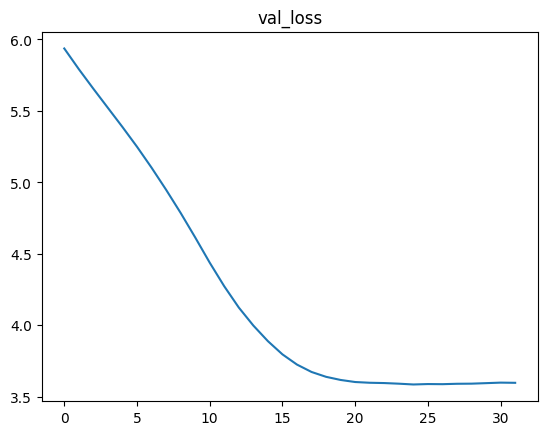

In [66]:
dict_to_plot(val_loss_dict, 'val_loss')

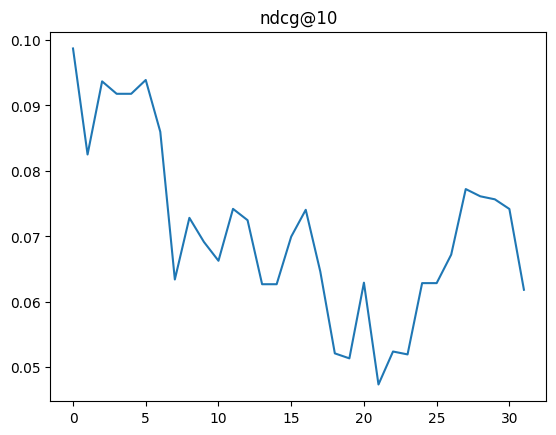

In [67]:
dict_to_plot(n10_dict, 'ndcg@10')

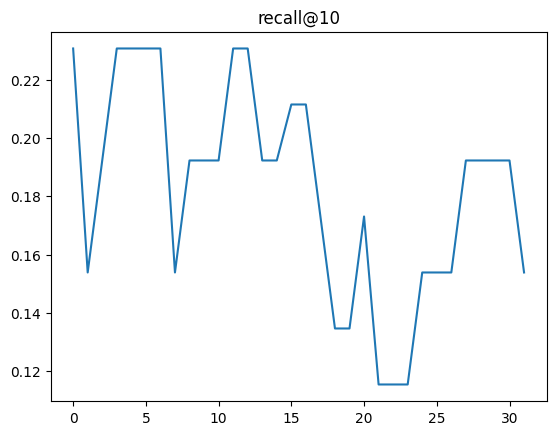

In [68]:
dict_to_plot(r10_dict, 'recall@10')

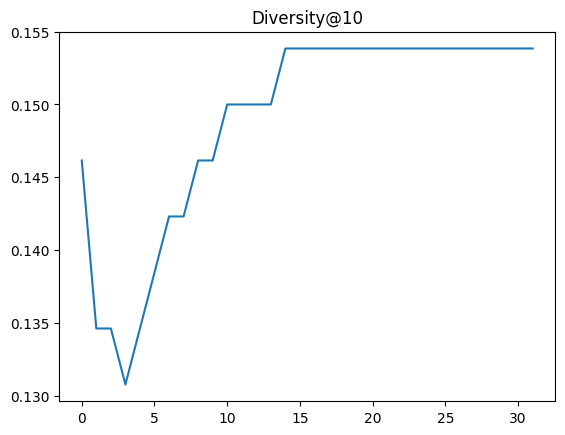

In [69]:
dict_to_plot(diversity10_dict, "Diversity@10")

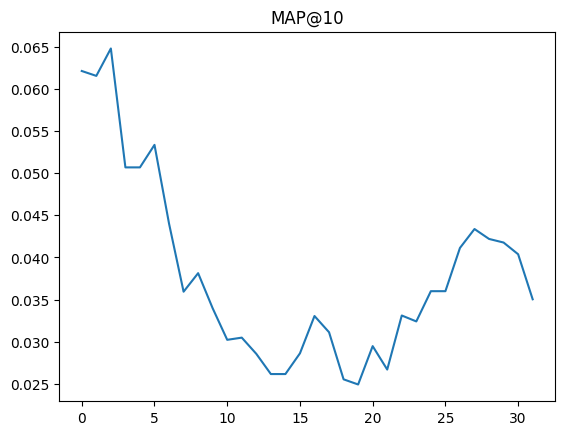

In [70]:
dict_to_plot(map10_dict, "MAP@10")

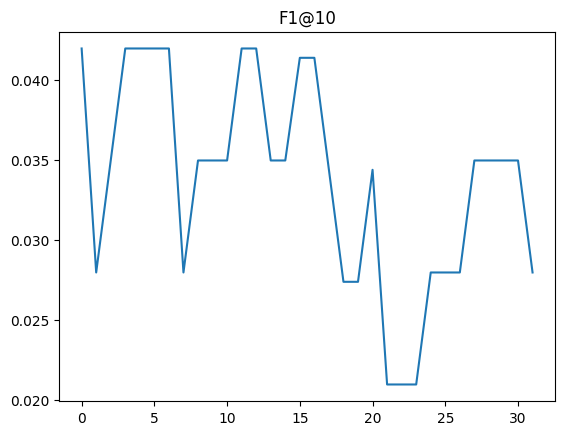

In [71]:
dict_to_plot(f1_10_dict, "F1@10")

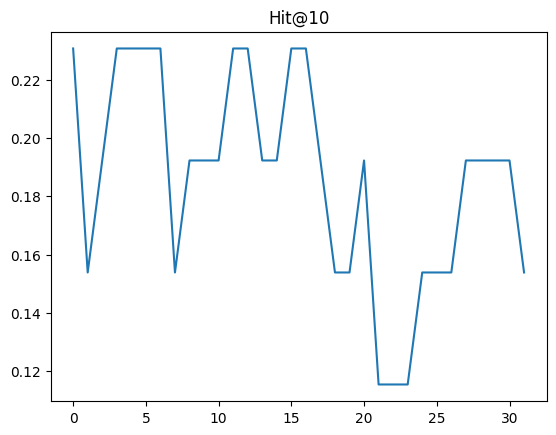

In [72]:
dict_to_plot(hit10_dict, "Hit@10")

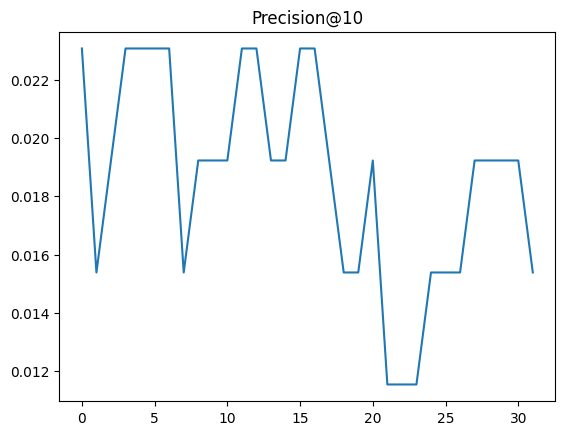

In [73]:
dict_to_plot(precision10_dict, "Precision@10")